# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## 8.1 Environment action plans

To investigate the effect of two recent national Danish aquatic environment action plans the concentration of nitrogen (measured in g/m$^3$) have been measured in a particular river just before the national action plans were enforced (1998 and 2003) and in 2011. Each measurement is repeated 6 times during a short stretch of river. The result is shown in the following table:

| N1998 | N2003 | N2011 |
|---|---|---|
| 5.01 | 5.59 | 3.02 |
| 6.23 | 5.13 | 4.76 |
| 5.98 | 5.33 | 3.46 |
| 5.31 | 4.65 | 4.12 |
| 5.13 | 5.52 | 4.51 |
| 5.65 | 4.92 | 4.42 |
| **Row means** | **5.5517** | **5.1900** | **4.0483** |

Further, the total variation in the data is $SST = 11.4944$.

You got the following output from Python corresponding to a one-way analysis of variance (where most of the information, however, is replaced by the letters A–E as well as U and V):

```python
fit = smf.ols('nitrogen ~ year', data=D).fit()
print(sm.stats.anova_lm(fit))
```
```
           Df   SumSq   MeanSq   Fvalue   Pr(>F)
Year        A       B        C        U        V
Residuals   D  4.1060        E
```

### a)
What numbers did the letters A–D substitute?

**Solution:**

A: represents the degrees of freedom for the factor "year". Since there are 3 levels (1998, 2003, 2011). $k-1 = 3-1 = 2$.

B: represents the sum of squares for the factor "year". This can be calculated as $SS_{between} = SST - SS_{within} = 11.4944 - 4.1060 = 7.3884$.

C: represents the mean square for the factor "year". This can be calculated as $MS_{between} = SS_{between} / (k-1) = 7.3884 / 2 = 3.6942$.

D: represents the degrees of freedom for the residuals. This can be calculated as $N - k = 18 - 3 = 15$.

In [2]:
n_total = 18 # TOtotal number of observations
k = 3 # from number of groups

n1998: np.ndarray[tuple[Any, ...], np.dtype[Unknown]] = np.array([5.01,6.23,5.98,5.31,5.13,5.65])
n2003: np.ndarray[tuple[Any, ...], np.dtype[Unknown]] = np.array([5.59,5.13,5.33,4.65,5.52,4.92])
n2011: np.ndarray[tuple[Any, ...], np.dtype[Unknown]] = np.array([3.02,4.76,3.46,4.12,4.51,4.42])

nitrogen = np.concatenate([n1998, n2003, n2011])
year = ['1998']*6 + ['2003']*6 + ['2011']*6

D = pd.DataFrame({'nitrogen': nitrogen, 'year': year})

fit = smf.ols('nitrogen ~ C(year)', data=D).fit()
print(sm.stats.anova_lm(fit, typ=1))



            df    sum_sq   mean_sq          F    PR(>F)
C(year)    2.0  7.388433  3.694217  13.495787  0.000444
Residual  15.0  4.105967  0.273731        NaN       NaN


### b)
If you use the significance level $\alpha = 0.05$, what critical value should be used for the hypothesis test carried out in the analysis (and in the table illustrated with the figures U and V)?

**Solution:**
The critical value for the F-test at $\alpha = 0.05$ with $k-1 = 2$ and $n-k = 15$ degrees of freedom is:

$$F_{0.95}(2, 15) = 3.682$$

We reject $H_0$ if $F_\text{obs} > 3.682$.

In [3]:
alpha = 0.05
print(stats.f.ppf(1 - alpha, dfn=k-1, dfd=n_total-k))

3.682320343673241


### c)
Can you with these data demonstrate statistically significant differences in the mean nitrogen concentrations from year to year (at significance level $\alpha = 0.05$)?

**Solution:**
Since $F_\text{obs} = 13.50 > F_{0.95}(2, 15) = 3.682$ (equivalently, p-value $= 0.0004 < \alpha = 0.05$),
we reject $H_0$ and conclude that there are statistically significant differences in mean 
nitrogen concentration between years.

### d)
Compute the 90% confidence interval for the mean difference between year 2011 and year 1998.

**Solution:**
Using Method 8.9 with MSE $= 0.2737$ from the ANOVA table and $t_{0.95}(15)$ from the t-distribution
with $n-k = 15$ degrees of freedom, the 90% confidence interval for $\mu_{2011} - \mu_{1998}$ is:

$$[-2.0329, -0.9739]$$

Since the interval is entirely negative, we conclude that the mean nitrogen concentration in 2011
is significantly lower than in 1998, consistent with a positive effect of the action plans.

In [11]:
alpha = 0.10
t = stats.t.ppf(1 - alpha/2, df=n_total-k)
MSE = 0.2737
ni = 6
nj = 6
y_2011 = 4.0483
y_1998 = 5.5517

diff = y_2011 - y_1998
ME = t * np.sqrt(MSE * (1/ni + 1/nj))
ci_lower = diff - ME
ci_upper = diff + ME
print(f"90% CI for mu_2011 - mu_1998: [{ci_lower:.4f}, {ci_upper:.4f}]")

90% CI for mu_2011 - mu_1998: [-2.0329, -0.9739]


## 8.2 Environment action plans (part 2)

This exercise uses the same data as Exercise 8.1. The table now also includes the variance computed within each group:

| N1998 | N2003 | N2011 |
|---|---|---|
| 5.01 | 5.59 | 3.02 |
| 6.23 | 5.13 | 4.76 |
| 5.98 | 5.33 | 3.46 |
| 5.31 | 4.65 | 4.12 |
| 5.13 | 5.52 | 4.51 |
| 5.65 | 4.92 | 4.42 |
| **Row means** | **5.5517** | **5.1900** | **4.0483** |
| **Row variances** | **0.2365767** | **0.1313200** | **0.4532967** |

Further, the overall mean of the data is $\bar{y} = 4.930$.

The raw data can be read into Python by the following code:
```python
nitrogen = np.array([
    5.01, 5.59, 3.02,
    6.23, 5.13, 4.76,
    5.98, 5.33, 3.46,
    5.31, 4.65, 4.12,
    5.13, 5.52, 4.51,
    5.65, 4.92, 4.42
])
year = pd.Categorical(np.tile(["1998", "2003", "2011"], 6))
D = pd.DataFrame({"nitrogen": nitrogen, "year": year})
```

### a)
Compute the three sums of squares ($SST$, $SS(Tr)$ and $SSE$) using the three means and three variances, and the overall mean (show the formulas explicitly).

**Solution:**

The formulas for the sums of squares are:

$$\text{SS(Tr)} = \sum_{j=1}^k n_j (\bar{y}_j - \bar{y})^2 = 6(5.5517 - 4.930)^2 + 6(5.1900 - 4.930)^2 + 6(4.0483 - 4.930)^2 = 7.3890$$

$$\text{SSE} = \sum_{j=1}^k (n_j - 1) s_j^2 = 5 \cdot 0.2366 + 5 \cdot 0.1313 + 5 \cdot 0.4533 = 4.1060$$

$$\text{SST} = \text{SS(Tr)} + \text{SSE} = 7.3890 + 4.1060 = 11.4950$$

In [12]:
y_bar = 4.930
means = np.array([5.5517, 5.1900, 4.0483])
variances = np.array([0.2365767, 0.1313200, 0.4532967])
n_groups = np.array([6, 6, 6])

SS_Tr = np.sum(n_groups * (means - y_bar)**2)
SSE = np.sum((n_groups - 1) * variances)
SST = SS_Tr + SSE

print(f"SS(Tr) = {SS_Tr:.4f}")
print(f"SSE    = {SSE:.4f}")
print(f"SST    = {SST:.4f}")

SS(Tr) = 7.3890
SSE    = 4.1060
SST    = 11.4950


### b)
Find the $SST$-value using Python's sample variance function `var(ddof=1)`.

**Solution:**

In [13]:
SST = (n_total - 1) * D['nitrogen'].var(ddof=1)
print(f"SST = {SST:.4f}")

SST = 11.4944


### c)
Run the ANOVA in Python and produce the ANOVA table.

**Solution:**

In [14]:
fit = smf.ols('nitrogen ~ C(year)', data=D).fit()
print(sm.stats.anova_lm(fit, typ=1))

            df    sum_sq   mean_sq          F    PR(>F)
C(year)    2.0  7.388433  3.694217  13.495787  0.000444
Residual  15.0  4.105967  0.273731        NaN       NaN


### d)
Do a complete post hoc analysis, where all the 3 years are compared pairwise.

**Solution:**
Performing all $M = k(k-1)/2 = 3$ pairwise comparisons using Tukey HSD (which controls the 
family-wise error rate at $\alpha = 0.05$):

- **1998 vs 2003**: mean difference $= -0.362$, p-value $= 0.473$ — not significant, no evidence of difference.
- **1998 vs 2011**: mean difference $= -1.503$, p-value $= 0.001$ — significant, nitrogen is lower in 2011.
- **2003 vs 2011**: mean difference $= -1.142$, p-value $= 0.005$ — significant, nitrogen is lower in 2011.

We conclude that the 2011 measurements are significantly lower than both 1998 and 2003, but 
there is no significant difference between 1998 and 2003. This suggests the action plans had 
a measurable effect by 2011.

In [15]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

alpha = 0.05

res = pairwise_tukeyhsd(endog=D['nitrogen'], groups=D['year'], alpha=alpha)
print(res)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  1998   2003  -0.3617 0.4727 -1.1463  0.4229  False
  1998   2011  -1.5033 0.0005 -2.2879 -0.7187   True
  2003   2011  -1.1417 0.0049 -1.9263 -0.3571   True
----------------------------------------------------


### e)
Use Python to do model validation by residual analysis.

**Solution:**
**Q-Q plot**: The points follow the straight line reasonably well with no severe deviations, 
supporting the normality assumption for the residuals.

**Residuals vs fitted**: The residuals are spread around zero at each of the three fitted values 
(the three group means). The spread looks roughly equal across groups, supporting the assumption 
of equal variance ($\sigma^2$) across groups.

Overall the model assumptions appear reasonable.

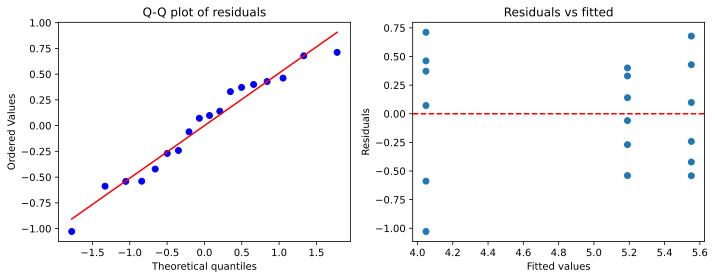

In [16]:
res = fit.resid
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(res, dist="norm", plot=ax[0])
ax[0].set_title('Q-Q plot of residuals')
ax[1].scatter(fit.fittedvalues, res)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('Fitted values')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residuals vs fitted')
plt.tight_layout()
plt.show()

## 8.3 Plastic film

A company is starting a production of a new type of patch. For the product a thin plastic film is to be used. Samples of products were received from 5 possible suppliers. Each sample consisted of 20 measurements of the film thickness and the following data were found:

| | Average film thickness $\bar{x}$ in $\mu$ m | Sample std. dev. $s$ in $\mu$ m |
|---|---|---|
| Supplier 1 | 31.4 | 1.9 |
| Supplier 2 | 30.6 | 1.6 |
| Supplier 3 | 30.5 | 2.2 |
| Supplier 4 | 31.3 | 1.8 |
| Supplier 5 | 29.2 | 2.2 |

From the usual calculations for a one-way analysis of variance the following is obtained:

| Source | Degrees of freedom | Sums of Squares |
|---|---|---|
| Supplier | 4 | $SS(Tr) = 62$ |
| Error | 95 | $SSE = 362.71$ |

### a)
Is there a significant ($\alpha = 5\%$) difference between the mean film thicknesses for the suppliers?

**Solution:** 

With $F_\text{obs} = 4.06 > F_{0.95}(4, 95) = 2.47$ (p-value $= 0.0044 < 0.05$), we reject $H_0$ 
and conclude that there are statistically significant differences in mean film thickness between 
the suppliers at $\alpha = 5\%$.

In [17]:
k = 5
n = 20 * k
alpha = 0.05

SS_tr = 62
SSE = 362.71

MS_tr = SS_tr / (k - 1)
MSE = SSE / (n - k)
F_obs = MS_tr / MSE

F_crit = stats.f.ppf(1 - alpha, dfn=k-1, dfd=n-k)
p_value = 1 - stats.f.cdf(F_obs, dfn=k-1, dfd=n-k)

print(f"F_obs  = {F_obs:.4f}")
print(f"F_crit = {F_crit:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"Reject H0: {F_obs > F_crit}")

F_obs  = 4.0597
F_crit = 2.4675
p-value = 0.0044
Reject H0: True


### b)
Compute a 95% confidence interval for the difference in mean film thicknesses of Supplier 1 and Supplier 4 (considered as a "single pre-planned" comparison).

**Solution:**

In [19]:
alpha = 0.05
t = stats.t.ppf(1 - alpha/2, df=n-k)
ni = 20
nj = 20
y_1 = 31.4
y_4 = 31.3

diff = y_1 - y_4
ME = t * np.sqrt(MSE * (1/ni + 1/nj))
ci_lower = diff - ME
ci_upper = diff + ME
print(f"95% CI for mu_1 - mu_4: [{ci_lower:.4f}, {ci_upper:.4f}]")


95% CI for mu_1 - mu_4: [-1.1267, 1.3267]


## 8.4 Brass alloys

When brass is used in a production, the modulus of elasticity, $E$, of the material is often important for the functionality. The modulus of elasticity for 6 different brass alloys are measured. 5 samples from each alloy are tested. The results (in GPa) are:

| | M1 | M2 | M3 | M4 | M5 | M6 |
|---|---|---|---|---|---|---|
| | 82.5 | 82.7 | 92.2 | 96.5 | 88.9 | 75.6 |
| | 83.7 | 81.9 | 106.8 | 93.8 | 89.2 | 78.1 |
| | 80.9 | 78.9 | 104.6 | 92.1 | 94.2 | 92.2 |
| | 95.2 | 83.6 | 94.5 | 87.4 | 91.4 | 87.3 |
| | 80.8 | 78.6 | 100.7 | 89.6 | 90.1 | 83.8 |

An analysis of variance is carried out using Python:
```python
fit = sm.ols('elasmodul ~ alloy', data=D).fit()
print(sm.stats.anova_lm(fit))
```
and the following output is obtained (some values replaced by A, B, C):
```
           df     sum_sq    mean_sq         F       PR(>F)
alloy       A    1192.51    238.501    9.9446    3.007e-05
Residuals   B          C     23.983
```

### a)
What are the values of A, B, and C?

**Solution:**

A: 5 degrees of freedom for the factor "alloy" (since there are 6 alloys, $k-1 = 6-1 = 5$).
B: 24 degrees of freedom for the residuals (since there are $n = 30$ total observations and $k = 6$ groups, $n-k = 30-6 = 24$).
C: The mean square for the residuals can be calculated as $SSE / (n-k) = 575.59 / 24 = 23.983$. where $SSE$ is the sum of squares for the residuals, which can be calculated as $SST - SS(Tr) = 1768.10 - 1192.51 = 575.59$.

In [22]:
k = 6
n = k*5

elasmodul = np.array([
    82.5, 83.7, 80.9, 95.2, 80.8,  # M1
    82.7, 81.9, 78.9, 83.6, 78.6,  # M2
    92.2, 106.8, 104.6, 94.5, 100.7,  # M3
    96.5, 93.8, 92.1, 87.4, 89.6,  # M4
    88.9, 89.2, 94.2, 91.4, 90.1,  # M5
    75.6, 78.1, 92.2, 87.3, 83.8   # M6
])
alloy = pd.Categorical(np.repeat(['M1','M2','M3','M4','M5','M6'], 5))
D = pd.DataFrame({'elasmodul': elasmodul, 'alloy': alloy})

fit = smf.ols('elasmodul ~ C(alloy)', data=D).fit()
print(sm.stats.anova_lm(fit, typ=1))

            df       sum_sq     mean_sq       F   PR(>F)
C(alloy)   5.0  1192.506667  238.501333  9.9446  0.00003
Residual  24.0   575.592000   23.983000     NaN      NaN


### b)
The assumptions for using the one-way analysis of variance is (choose the answer that lists all the assumptions and that does NOT list any unnecessary assumptions):

1) The data must be normally and independently distributed within each group and the variances within each group should not differ significantly from each other
2) The data must be normally and independently distributed within each group
3) The data must be normally and independently distributed and have approximately the same mean and variance within each group
4) The data should not be too large or too small
5) The data must be normally and independently distributed within each group and have approximately the same IQR-value in each group

**Solution:**

one is the correct answer: 1) The data must be normally and independently distributed within each group and the variances within each group should not differ significantly from each other

### c)
Compute a 95% confidence interval for the single pre-planned difference between brass alloy 1 and 2.

**Solution:**

In [24]:
alpha = 0.05
t = stats.t.ppf(1 - alpha/2, df=n-k)
ni = 5
nj = 5
y_1 = D[D['alloy'] == 'M1']['elasmodul'].mean()
y_2 = D[D['alloy'] == 'M2']['elasmodul'].mean()

MSE = 23.983

diff = y_1 - y_2
ME = t * np.sqrt(MSE * (1/ni + 1/nj))
ci_lower = diff - ME
ci_upper = diff + ME
print(f"95% CI for mu_1 - mu_2: [{ci_lower:.4f}, {ci_upper:.4f}]")


95% CI for mu_1 - mu_2: [-2.9125, 9.8725]


## E9 Lecture exercises

## Exercise 1.8: Lecture 10

This exercise use the data from Example 8.26, and you can read the data into
Python by
```python
dat = pd.read_csv("cars.csv", sep=';')
dat
```

```txt
car tire fuel
1 1 1 22.5
2 1 2 21.5
3 1 3 22.2
4 2 1 24.3
5 2 2 21.3
6 2 3 21.9
7 3 1 24.9
8 3 2 23.9
9 3 3 21.7
10 4 1 22.4
11 4 2 18.4
12 4 3 17.9
```

## E9.17 Helmert transformation

### a)
With reference to (9-243), show that

$$T H_N = \begin{bmatrix} 1 & -1/2 & -1/3 & -1/4 & \cdots & -1/k \\ 1 & 1/2 & -1/3 & -1/4 & \cdots & -1/k \\ 1 & 0 & 2/3 & -1/4 & \cdots & -1/k \\ 1 & 0 & 0 & 3/4 & \cdots & -1/k \\ \vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & 0 & \cdots & 0 & & (k-1)/k \end{bmatrix}.$$

**Solution:**

### b)
Using $X$ as in (9-234), show that

$$X^T H_N = \begin{bmatrix} 1 & -\frac{1}{2} \mathbf{1} & -\frac{1}{3} \mathbf{1} & \cdots & -\frac{1}{k} \mathbf{1} \\ 1 & \frac{1}{2} \mathbf{1} & -\frac{1}{3} \mathbf{1} & \cdots & -\frac{1}{k} \mathbf{1} \\ 1 & 0 & \frac{2}{3} \mathbf{1} & \cdots & -\frac{1}{k} \mathbf{1} \\ \vdots & \vdots & \vdots & & \vdots \\ 1 & 0 & 0 & \cdots & \frac{k-1}{k} \mathbf{1} \end{bmatrix}.$$

**Solution:**

### c)
Show that

$$(X^T H_N X H_N)^{-1} = \frac{1}{n} \begin{bmatrix} \frac{1}{k} & 0 & 0 & \cdots & 0 \\ 0 & 2 & 0 & \cdots & 0 \\ 0 & 0 & \frac{3}{2} & \cdots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & 0 & \cdots & \frac{k}{k-1} \end{bmatrix}.$$

**Solution:**

### d)
Use the above to prove (9-244).

**Solution:**